## Imports

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
sys.path.append(os.path.abspath(".."))
from fields import RandomField
from simulations import Simulator, compare_simulators
import matplotlib.pyplot as plt 
import jax.numpy as jnp

In [2]:
f1 = RandomField(size=jnp.array([10.]), seed=2, delta_k=0.2*jnp.pi, interpolate=False, verbose=False, tesselate=False)
f2 = RandomField(size=jnp.array([8., 8.]), seed=5, delta_k=0.2*jnp.pi, interpolate=False, verbose=False, tesselate=False)
f3 = RandomField(size=jnp.array([8., 8., 8.]), seed=2, delta_k=0.05*jnp.pi, interpolate=False, verbose=False, tesselate=False)

## Simulation

loaded Simulator from data/sim_1d with parameters: Field type: RandomField, 
D: 1, n_particles: 2^5, seed: 42, name: Simulator_b460ec5c0295dd66 
dt: 0.002, t_end: 8.2, delta_t_save: 0.002, 

opened existing zarr store


Evaluating field on grid of size (501,) for plotting...
Done evaluating field on grid, now plotting...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


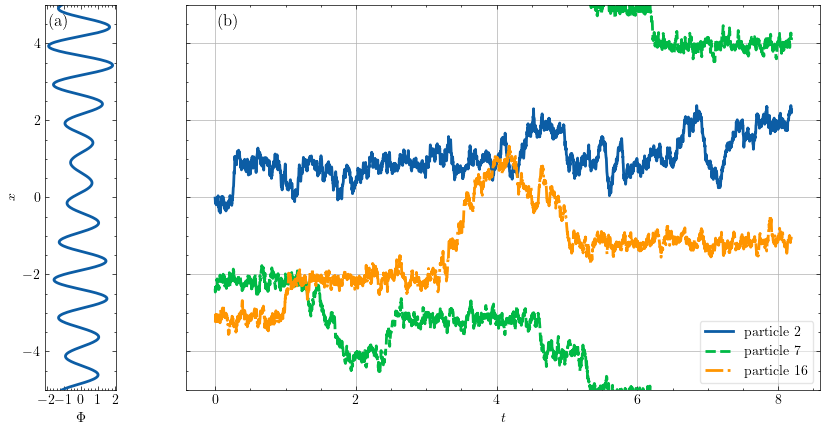

In [3]:
# sim_1d = Simulator(f1, n_particles=32, n_timesteps=2**12, storage_dir="data/sim_1d", verbose=False)
# sim_1d.run(save_continuous=True, save_discretized=False, save_mfpts=False, save_transitions=False, save_propagator=False, recompute=False, verbose=False)
sim_1d = Simulator.from_file("data/sim_1d")
sim_1d.plot_sample(seed=6)
plt.savefig("figures/sim_1d.eps")

Evaluating field on grid of size (401, 401) for plotting...
Done evaluating field on grid, now plotting...


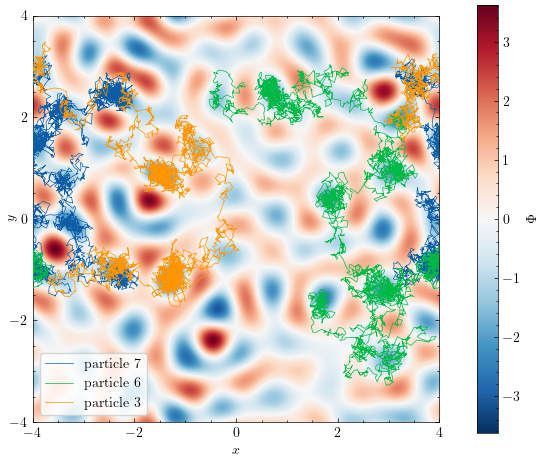

: 

In [ ]:
sim_2d = Simulator(f2, n_particles=2**4, n_timesteps=2**12, storage_dir="data/crap2", verbose=False)
sim_2d.run(save_continuous=True, save_discretized=False, save_mfpts=False, save_transitions=False, save_propagator=False, recompute=False, verbose=False)
sim_2d.plot_sample(linewidth=0.5, line_styles=["-"], seed=1)
# plt.savefig("figures/sim_2d.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


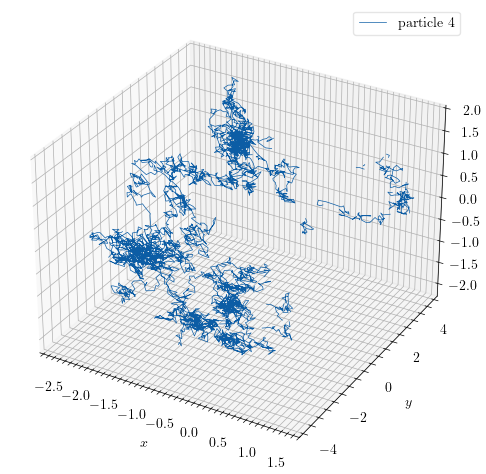

In [ ]:
sim_3d = Simulator(f3, n_particles=2**4, n_timesteps=2**12, storage_dir="data/sim_3d", verbose=False)
sim_3d.run(save_continuous=True, save_discretized=False, save_mfpts=False, save_transitions=False, save_propagator=False, recompute=False, verbose=False)
sim_3d.plot_sample(linewidth=0.5, line_styles=["-"], ids=jnp.array([4]))
# plt.savefig("figures/sim_3d.eps")

## Simulator Comparison

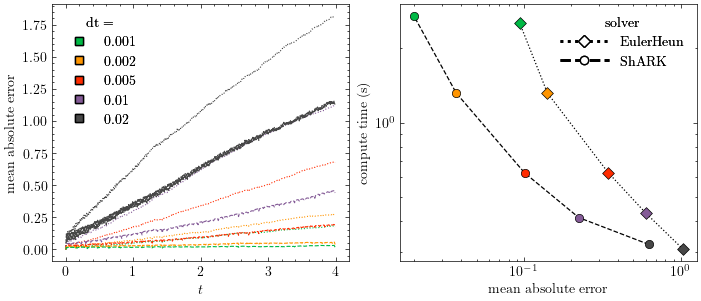

In [ ]:
compare_simulators(f2, n_particles=2**10, t_end=4., dts=[0.02, 0.01, 0.005, 0.002, 0.001, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0002], solvers=["EulerHeun"] * 5 + ["ShARK"] * 6, batch_size=2**7, recompute=False, verbose=False, ids=jnp.array([]))
# plt.savefig("figures/sim_comparison.eps")

Evaluating field on grid of size (301, 251) for plotting...
Done evaluating field on grid, now plotting...


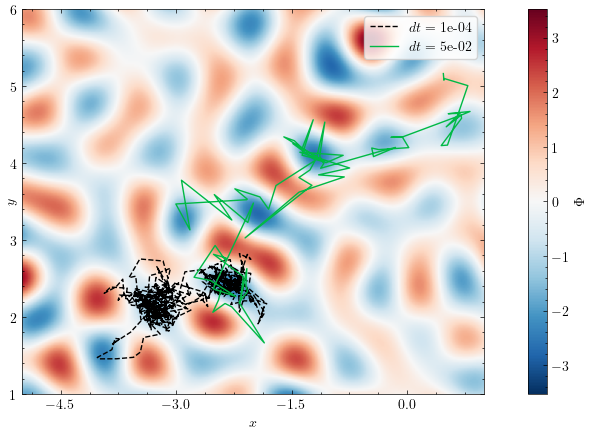

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
f2.plot_field(ax_x=ax, show_cells=False, bounds=jnp.array([[-5., 1.], [1., 6.]]))
for dt, ls, c in zip([1e-4, 5e-2], ['--', '-'], ['k', COLORS[1]]):
    sim = Simulator(f2, n_particles=16, t_end=4., dt=dt, delta_t_save=0.01, solver="ShARK", verbose=False, storage_dir=f"data/sim_comparison_n16_b16_t4.0/dt{dt:.1e}_ShARK")
    sim.run(save_continuous=True, save_discretized=False, save_propagator=False, save_final=False, save_transitions=False, save_mfpts=False, batch_size=16, recompute=False, verbose=False)
    traj_cont = sim.zarr_root["traj_cont"][:]
    i = 9
    ax.plot(traj_cont[i, :, 0], traj_cont[i, :, 1], label=f"$dt=$ {dt:.0e}", lw=1, ls=ls, color=c)

ax.legend(frameon=True)
# plt.savefig("figures/sim_comparison_trajectories.eps")